# Learning Rules

**SC-NeuroCore v3.14** — 13 plasticity mechanisms from STDP to meta-learning.

This notebook demonstrates six learning rules side by side:

1. **STDP** — spike-timing-dependent plasticity (built into Projection)
2. **BPTT** — backpropagation through time with surrogate gradients
3. **E-prop** — eligibility trace (three-factor: pre × post × error)
4. **R-STDP** — reward-modulated STDP
5. **Homeostatic** — target rate maintenance
6. **STP** — short-term facilitation and depression

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore import StochasticLIFNeuron
from sc_neurocore.network.population import Population
from sc_neurocore.network.projection import Projection
from sc_neurocore.network.network import Network
from sc_neurocore.network.monitor import SpikeMonitor
from sc_neurocore.network.stimulus import PoissonInput
from sc_neurocore.learning.advanced import (
    BPTTLearner,
    EligibilityTrace,
    RewardModulatedLearner,
    HomeostaticPlasticity,
    ShortTermPlasticity,
)

print("SC-NeuroCore learning rules demo")

SC-NeuroCore learning rules demo


## 1. STDP: Spike-Timing-Dependent Plasticity

STDP modifies synaptic weights based on the relative timing of
pre- and post-synaptic spikes:

- Pre before post (causal): potentiation ($\Delta w > 0$)
- Post before pre (anti-causal): depression ($\Delta w < 0$)

SC-NeuroCore implements STDP natively in `Projection` when
`plasticity="stdp"` is set.

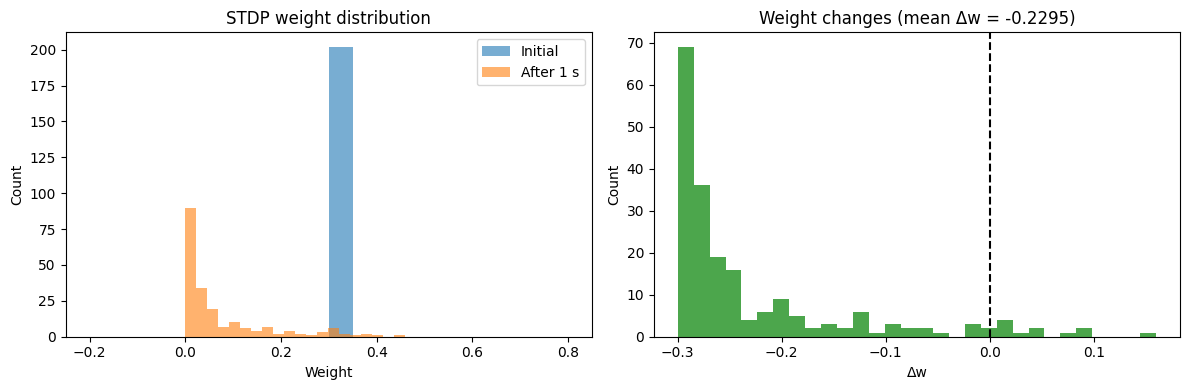

Spikes: 1477
Synapses: 202
Potentiated: 13, Depressed: 189


In [2]:
pop_pre = Population(StochasticLIFNeuron, n=20, label="pre")
pop_post = Population(StochasticLIFNeuron, n=20, label="post")

proj = Projection(
    pop_pre, pop_post,
    weight=0.3, probability=0.5,
    plasticity="stdp", seed=42,
)

drive = PoissonInput(n=20, rate_hz=100.0, weight=2.0, dt=0.001, seed=42)
mon = SpikeMonitor(pop_post, label="post_spk")

net = Network(pop_pre, pop_post, proj, drive, mon)

# Record weight evolution
w_init = proj.data.copy()

# Run for 1 second
net.run(duration=1.0, dt=0.001)

w_final = proj.data.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(w_init, bins=20, alpha=0.6, label="Initial")
axes[0].hist(w_final, bins=20, alpha=0.6, label="After 1 s")
axes[0].set_xlabel("Weight")
axes[0].set_ylabel("Count")
axes[0].set_title("STDP weight distribution")
axes[0].legend()

dw = w_final - w_init
axes[1].hist(dw, bins=30, alpha=0.7, color="green")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_xlabel("\u0394w")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Weight changes (mean \u0394w = {np.mean(dw):.4f})")

plt.tight_layout()
plt.show()

print(f"Spikes: {mon.count}")
print(f"Synapses: {len(proj.data)}")
print(f"Potentiated: {np.sum(dw > 0.001)}, Depressed: {np.sum(dw < -0.001)}")

## 2. Eligibility Trace (E-prop)

Three-factor learning (Bellec et al. 2020): eligibility traces
accumulate pre×post coincidences with exponential decay, then
weight updates are gated by a top-down error signal.

$$\Delta w_{ij} = \eta \cdot e_{ij} \cdot \text{error}_j$$

where $e_{ij}$ is the eligibility trace decaying with $\tau_e$.

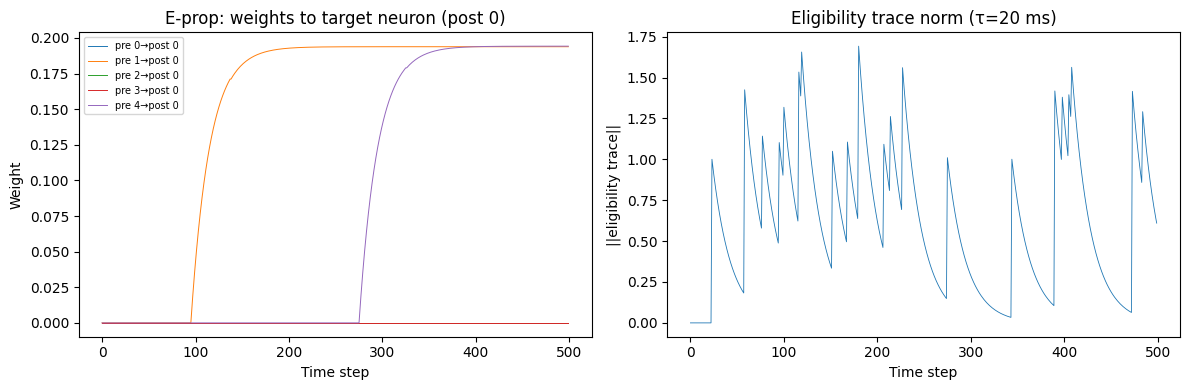

In [3]:
N_PRE, N_POST = 10, 5
T = 500

etrace = EligibilityTrace(tau_e=20.0, dt=1.0)

np.random.seed(42)
weights = np.zeros((N_PRE, N_POST))
lr = 0.01

weight_history = []
trace_norms = []

for t in range(T):
    pre_spike = (np.random.random(N_PRE) < 0.05).astype(float)
    post_spike = (np.random.random(N_POST) < 0.03).astype(float)

    # Error signal: target high activity on neuron 0, low elsewhere
    target = np.array([1.0, 0.0, 0.0, 0.0, 0.0])
    error = target - post_spike

    dw = etrace.update(pre_spike, post_spike, error)
    weights += lr * dw

    weight_history.append(weights.copy())
    trace_norms.append(np.linalg.norm(etrace._trace))

weight_history = np.array(weight_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weight evolution for connections to neuron 0 (target)
for i in range(min(5, N_PRE)):
    axes[0].plot(weight_history[:, i, 0], linewidth=0.7, label=f"pre {i}\u2192post 0")
axes[0].set_xlabel("Time step")
axes[0].set_ylabel("Weight")
axes[0].set_title("E-prop: weights to target neuron (post 0)")
axes[0].legend(fontsize=7)

axes[1].plot(trace_norms, linewidth=0.6)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("||eligibility trace||")
axes[1].set_title("Eligibility trace norm (\u03c4=20 ms)")

plt.tight_layout()
plt.show()

## 3. Reward-Modulated STDP (R-STDP)

R-STDP maintains per-synapse eligibility traces from STDP-like
coincidence detection, but delays weight updates until a global
reward signal arrives. This bridges the temporal credit
assignment gap in reinforcement learning.

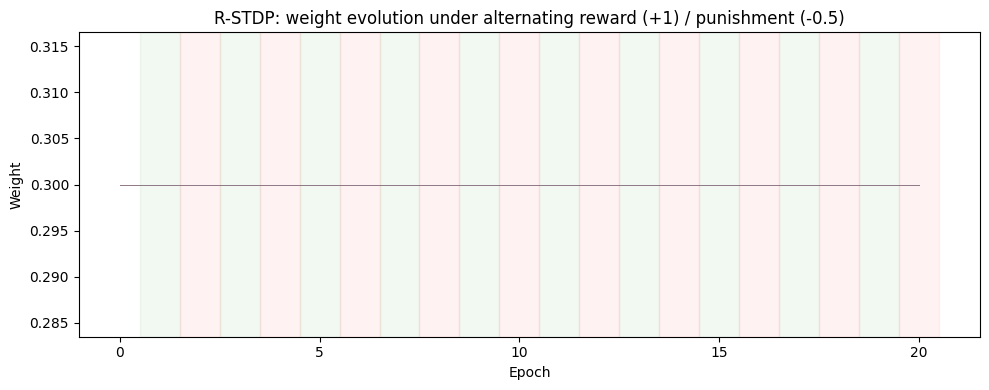

In [4]:
pop_a = Population(StochasticLIFNeuron, n=10, label="a")
pop_b = Population(StochasticLIFNeuron, n=5, label="b")
proj_ab = Projection(pop_a, pop_b, weight=0.3, probability=0.8, seed=7)
drive_a = PoissonInput(n=10, rate_hz=80.0, weight=2.0, dt=0.001, seed=99)
mon_b = SpikeMonitor(pop_b, label="b_spk")

net_rl = Network(pop_a, pop_b, proj_ab, drive_a, mon_b)
rstdp = RewardModulatedLearner(net_rl, tau_reward=100.0)

w_history_rl = [proj_ab.data.copy()]

# Simulate with alternating reward/punishment
for epoch in range(20):
    net_rl.run(duration=0.05, dt=0.001)  # 50 ms
    reward = 1.0 if epoch % 2 == 0 else -0.5
    rstdp.step(reward=reward)
    w_history_rl.append(proj_ab.data.copy())

w_history_rl = np.array(w_history_rl)

fig, ax = plt.subplots(figsize=(10, 4))
for s in range(min(8, w_history_rl.shape[1])):
    ax.plot(w_history_rl[:, s], linewidth=0.7, alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Weight")
ax.set_title("R-STDP: weight evolution under alternating reward (+1) / punishment (-0.5)")

# Shade reward/punishment epochs
for e in range(20):
    color = "green" if e % 2 == 0 else "red"
    ax.axvspan(e + 0.5, e + 1.5, alpha=0.05, color=color)

plt.tight_layout()
plt.show()

## 4. Short-Term Plasticity (STP)

Tsodyks-Markram model (1997): synaptic efficacy changes on
timescales of tens to hundreds of ms.

- **Facilitation**: repeated spikes increase release probability
- **Depression**: vesicle depletion reduces release probability

The balance between facilitation and depression determines
whether a synapse acts as a high-pass or low-pass temporal filter.

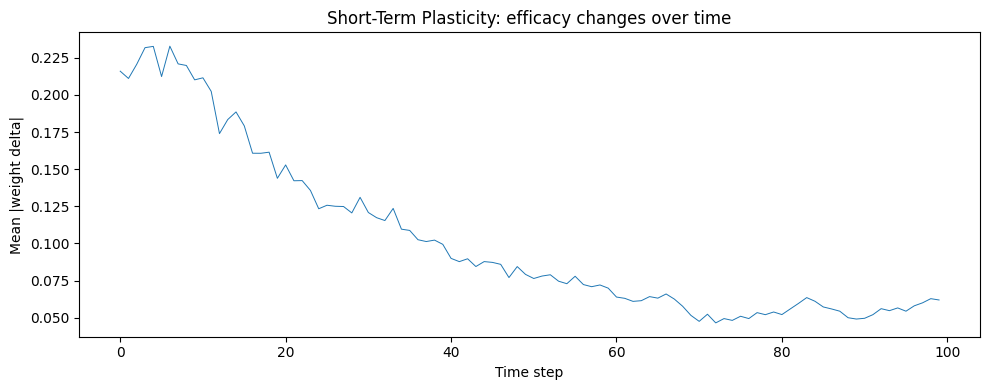

In [5]:
# STP: Short-term plasticity operates on population spike vectors.
# ShortTermPlasticity.update(pre_spikes: np.ndarray) → np.ndarray
stp = ShortTermPlasticity(tau_d=200.0, tau_f=600.0, u_se=0.2)

# Simulate 10 timesteps with random population spikes
n_pre = 20
T_stp = 100
efficacy_trace = np.zeros(T_stp)

for t in range(T_stp):
    pre = (np.random.random(n_pre) < 0.1).astype(float)
    delta = stp.update(pre)
    efficacy_trace[t] = np.mean(np.abs(delta))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(efficacy_trace, linewidth=0.7)
ax.set_xlabel("Time step")
ax.set_ylabel("Mean |weight delta|")
ax.set_title("Short-Term Plasticity: efficacy changes over time")
plt.tight_layout()
plt.show()

## Summary

| Rule | Class | Timescale | Use case |
|------|-------|-----------|----------|
| STDP | `Projection(plasticity="stdp")` | Seconds | Unsupervised structure learning |
| BPTT | `BPTTLearner` | Full sequence | Supervised temporal tasks |
| E-prop | `EligibilityTrace` | 10-100 ms decay | Online credit assignment |
| R-STDP | `RewardModulatedLearner` | Reward delay | Reinforcement learning |
| Homeostatic | `HomeostaticPlasticity` | Minutes | Rate stabilisation |
| STP | `ShortTermPlasticity` | 50-500 ms | Temporal filtering |
| TBPTT | `TBPTTLearner` | Chunked | Long sequences (memory-efficient) |
| MAML | `MetaLearner` | Tasks | Few-shot adaptation |
| Structural | `StructuralPlasticity` | Hours | Synapse birth/pruning |
| BCM | `learning.bcm` | Seconds | Sliding-threshold metaplasticity |
| Voltage STDP | `learning.voltage_stdp` | Seconds | Clopath et al. 2010 |
| EWC | `learning.ewc` | Tasks | Continual learning (Kirkpatrick 2017) |

All rules work with the Population-Projection-Network API.